## Phase 1: Data Set Details
**Goal:** understand the data before any analysis or modelling.

# 1.Setup and Load

In [72]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os

DATA_PATH = '../data/stock_risk_prediction_dataset.xlsx'
CLEAN_PATH = '../data/cleaned_stock_risk_prediction_dataset.csv'

#By default, pandas hides middle columns of wide tables and shows ... instead. None means "no limit", so all 11 columns always show when you print a table.
pd.set_option('display.max_columns', None)

# Seperating the coulumns based on their data types
NUMERIC = ["current_stock", "avg_daily_demand", "lead_time_days", "reorder_point",
           "sales_last_30_days", "stock_turnover_ratio", "forecast_error"]
CATEGORICAL = ["season", "item_category", "supplier_reliability"]
TARGET = "stock_status"


df = pd.read_excel(DATA_PATH)
df.head()


,current_stock,avg_daily_demand,lead_time_days,reorder_point,sales_last_30_days,stock_turnover_ratio,forecast_error,season,item_category,supplier_reliability,stock_status
0,549,45.76,5.64,342.83,1604.49,4.17,-9.90,peak,essential,low,overstock
1,486,45.47,6.39,348.37,1585.00,4.01,-5.27,peak,non-essential,high,overstock
2,564,32.04,5.81,353.21,1219.04,3.57,-2.94,off-peak,non-essential,high,overstock
3,652,46.70,7.22,397.34,1673.88,4.00,0.75,off-peak,essential,low,overstock
4,476,57.33,9.39,312.64,1052.98,4.49,5.12,peak,essential,high,overstock


## 2. Shape , Columns and data Types

In [73]:
print("Rows x Columns:", df.shape, "  (expected 5000 x 11)")

expected_cols = NUMERIC + CATEGORICAL + [TARGET]
print("Missing expected columns:", [c for c in expected_cols if c not in df.columns] or "none")
print("Unexpected extra columns:", [c for c in df.columns if c not in expected_cols] or "none")

Rows x Columns: (5000, 11)   (expected 5000 x 11)
Missing expected columns: none
Unexpected extra columns: none


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   current_stock         5000 non-null   int64  
 1   avg_daily_demand      5000 non-null   float64
 2   lead_time_days        5000 non-null   float64
 3   reorder_point         5000 non-null   float64
 4   sales_last_30_days    5000 non-null   float64
 5   stock_turnover_ratio  5000 non-null   float64
 6   forecast_error        5000 non-null   float64
 7   season                5000 non-null   object 
 8   item_category         5000 non-null   object 
 9   supplier_reliability  5000 non-null   object 
 10  stock_status          5000 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 429.8+ KB


**Check:** numeric columns should show `int64`/`float64`, categorical and target columns `object`. A number stored as `object` means there is text in that column that must be fixed.


In [75]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2),
})
if missing.missing_count.sum():
    display(missing[missing.missing_count > 0])
else:
    print("No missing values")

No missing values


In [76]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [77]:
EXPECTED_VALUES = {
    "season": {"peak", "off-peak"},
    "item_category": {"essential", "non-essential"},
    "supplier_reliability": {"high", "low"},
    "stock_status": {"stockout", "overstock"},
}

for col, expected in EXPECTED_VALUES.items():
    found = set(df[col].dropna().unique())
    print(f"{col:22s} found: {sorted(map(str, found))}")
    unexpected = found - expected
    if unexpected:
        print(f"   -> unexpected labels (case/spacing issues?): {sorted(map(str, unexpected))}")

season                 found: ['off-peak', 'peak']
item_category          found: ['essential', 'non-essential']
supplier_reliability   found: ['high', 'low']
stock_status           found: ['overstock', 'stockout']


In [78]:
rows = []
for col in NUMERIC:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((df[col] < low) | (df[col] > high)).sum())
    rows.append({"column": col, "lower_fence": round(low, 2), "upper_fence": round(high, 2),
                 "outlier_count": n, "outlier_percent": round(n / len(df) * 100, 2)})
pd.DataFrame(rows)

,column,lower_fence,upper_fence,outlier_count,outlier_percent
0,current_stock,236.00,764.00,42,0.84
1,avg_daily_demand,22.67,77.24,34,0.68
2,lead_time_days,1.67,12.36,48,0.96
3,reorder_point,213.91,488.18,36,0.72
4,sales_last_30_days,680.90,2303.74,23,0.46
5,stock_turnover_ratio,1.23,6.75,26,0.52
6,forecast_error,-14.01,13.92,34,0.68


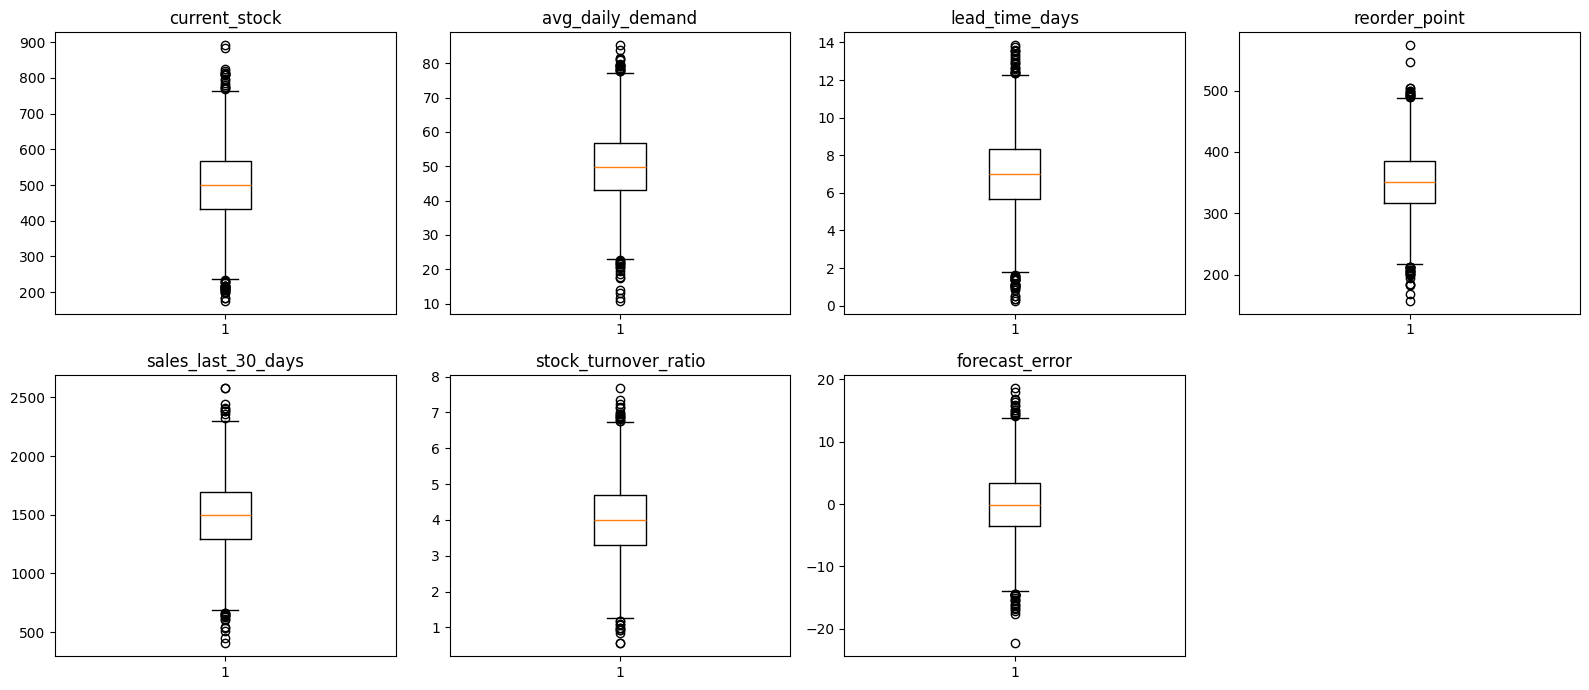

In [79]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

In [80]:
df[NUMERIC].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
current_stock,5000.0,500.07,99.65,175.00,434.00,501.00,566.00,892.00
avg_daily_demand,5000.0,49.90,10.10,10.78,43.13,49.82,56.77,85.29
lead_time_days,5000.0,7.02,2.00,0.25,5.68,7.02,8.35,13.86
reorder_point,5000.0,350.83,50.17,157.18,316.76,350.96,385.33,573.95
sales_last_30_days,5000.0,1494.49,295.01,403.47,1289.47,1497.59,1695.18,2583.41
stock_turnover_ratio,5000.0,3.99,1.00,0.55,3.30,4.00,4.68,7.69
forecast_error,5000.0,-0.05,5.13,-22.33,-3.54,-0.12,3.44,18.64


In [81]:
for col in CATEGORICAL:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- season ---
season
off-peak    2508
peak        2492
Name: count, dtype: int64

--- item_category ---
item_category
essential        2505
non-essential    2495
Name: count, dtype: int64

--- supplier_reliability ---
supplier_reliability
low     2514
high    2486
Name: count, dtype: int64



,count,percent
stock_status,,
overstock,4543,90.9
stockout,457,9.1


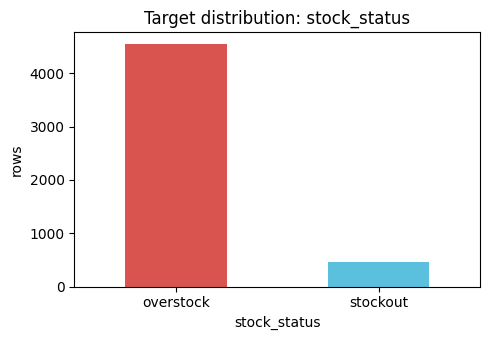

Minority class is under 30%: plan to use class_weight='balanced' or SMOTE in model building.


In [82]:
counts = df[TARGET].value_counts(dropna=False)
percent = df[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(1)
display(pd.DataFrame({"count": counts, "percent": percent}))

ax = counts.plot(kind="bar", color=["#d9534f", "#5bc0de"], figsize=(5, 3.5), rot=0)
ax.set_title("Target distribution: stock_status")
ax.set_ylabel("rows")
plt.tight_layout()
plt.show()

if percent.min() < 30:
    print("Minority class is under 30%: plan to use class_weight='balanced' or SMOTE in model building.")
else:
    print("Classes are reasonably balanced.")

In [83]:
clean = df.copy()

# 1. standardise text labels
for col in CATEGORICAL + [TARGET]:
    clean[col] = clean[col].astype("string").str.strip().str.lower()

# 2. remove duplicates
before = len(clean)
clean = clean.drop_duplicates()
print("Duplicates removed:", before - len(clean))

# 3. drop rows with missing target (cannot train on them)
before = len(clean)
clean = clean.dropna(subset=[TARGET])
print("Rows dropped (missing target):", before - len(clean))

# 4. fill missing feature values: median for numeric, mode for categorical
for col in NUMERIC:
    if clean[col].isnull().any():
        clean[col] = clean[col].fillna(clean[col].median())
for col in CATEGORICAL:
    if clean[col].isnull().any():
        clean[col] = clean[col].fillna(clean[col].mode()[0])

# 5. drop impossible rows
bad = (clean["current_stock"] < 0) | (clean["avg_daily_demand"] < 0) | (clean["lead_time_days"] < 0)
print("Rows dropped (negative stock/demand/lead time):", int(bad.sum()))
clean = clean[~bad]

print("\nFinal clean shape:", clean.shape)
print("Missing values left:", int(clean.isnull().sum().sum()))

Duplicates removed: 0
Rows dropped (missing target): 0
Rows dropped (negative stock/demand/lead time): 0

Final clean shape: (5000, 11)
Missing values left: 0


In [84]:
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)
clean.to_csv(CLEAN_PATH, index=False)
print("Saved ->", CLEAN_PATH)
clean.head()

Saved -> ../data/cleaned_stock_risk_prediction_dataset.csv


,current_stock,avg_daily_demand,lead_time_days,reorder_point,sales_last_30_days,stock_turnover_ratio,forecast_error,season,item_category,supplier_reliability,stock_status
0,549,45.76,5.64,342.83,1604.49,4.17,-9.90,peak,essential,low,overstock
1,486,45.47,6.39,348.37,1585.00,4.01,-5.27,peak,non-essential,high,overstock
2,564,32.04,5.81,353.21,1219.04,3.57,-2.94,off-peak,non-essential,high,overstock
3,652,46.70,7.22,397.34,1673.88,4.00,0.75,off-peak,essential,low,overstock
4,476,57.33,9.39,312.64,1052.98,4.49,5.12,peak,essential,high,overstock
